## Building Chat Bot With MultipleTools

In [ ]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from  langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

In [ ]:
api_wrapper_arxiv = ArxivAPIWrapper(
    top_k_results=2,
    doc_content_chars_max=500
)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [ ]:
api_wrapper_wikki = WikipediaAPIWrapper(
    top_k_results=1,
    doc_content_chars_max=500  
)
wikki = WikipediaQueryRun(api_wrapper=api_wrapper_wikki)
print(wikki.name)

wikipedia


In [ ]:
### LOAD TAVILY API KEY 
from dotenv import load_dotenv
import os
load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")




In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults(

)

In [ ]:
tavily

TavilySearchResults(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))

In [54]:
Tools = [arxiv,wikki,tavily]

In [55]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="openai/gpt-oss-120b"
)
llm_with_tools = llm.bind_tools(Tools)

In [56]:
from pprint import pprint
from langchain_core.messages import AIMessage,HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is recent Ai News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest AI news September 2026'},
  'id': 'fc_f4b5e0df-03ca-4c72-9263-ffeb132b4a87',
  'type': 'tool_call'}]

In [57]:
from IPython.display import Image,display
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph import START,END,StateGraph
from langgraph.graph import add_messages
from langgraph.prebuilt import tool_node,tools_condition


class State(TypedDict):
    message:Annotated[list[AnyMessage],add_messages]

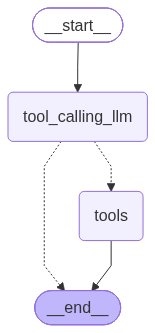

In [58]:
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state: State):
    return {
        "messages": [
            llm_with_tools.invoke(state["message"])
        ]
    }


builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)

builder.add_node("tools", ToolNode(Tools))

builder.add_edge(START, "tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [59]:
def tool_calling_llm(state: State):
    response = llm_with_tools.invoke(state["messages"])

    print("\n===== LLM RESPONSE =====")
    response.pretty_print()

    return {
        "messages": [response]
    }

In [60]:
result = graph.invoke({
    "messages": [
        HumanMessage(content="Search the web for the latest LangGraph news")
    ]
})

BadRequestError: Error code: 400 - {'error': {'message': "'messages' : minimum number of items is 1", 'type': 'invalid_request_error'}}